<a href="https://colab.research.google.com/github/MarioViniciusBC/regressao_linear/blob/main/minimos_quadrados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Regresão linear por mínimos quadrados**

**Problema:** Dado um conjunto de dados tabelados, obtido geralmente de uma coleta experimental, obter a melhor reta que ajusta esses pontos pelo método dos mínimos quadrados (MMQ).

### **Método dos mínimos quadrados (MMQ)**

Veja o gráfico a seguir:

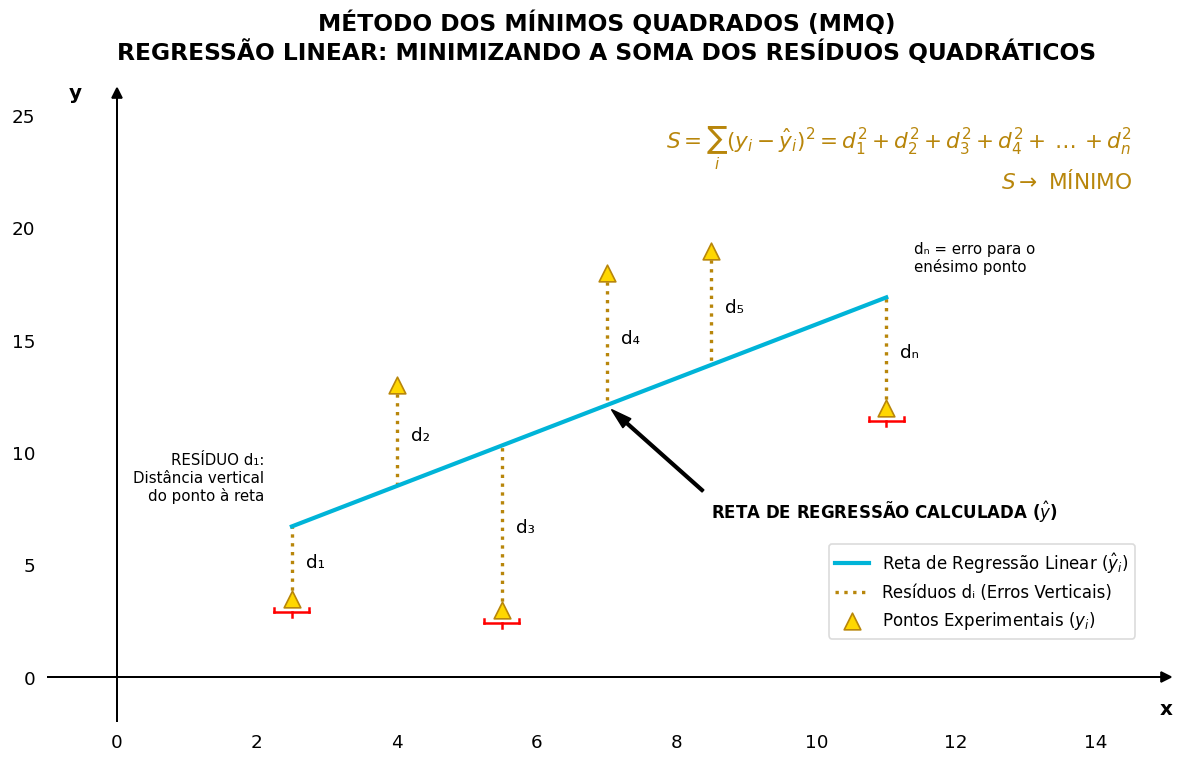

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Configurações para tema claro (fundo branco)
plt.style.use('default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120 # Resolução ajustada para Colab

# Dados sintéticos
x = np.array([2.5, 4, 5.5, 7, 8.5, 11])
y = np.array([3.5, 13, 3, 18, 19, 12])
labels_d = ['d₁', 'd₂', 'd₃', 'd₄', 'd₅', 'dₙ']

# Cálculo da reta de regressão linear (MMQ)
n = len(x)
beta1 = (n * np.sum(x * y) - np.sum(x) * np.sum(y)) / (n * np.sum(x**2) - (np.sum(x))**2)
beta0 = np.mean(y) - beta1 * np.mean(x)
y_hat = beta0 + beta1 * x

# Geração do gráfico
fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Configuração de limites
ax.set_xlim(left=-1, right=15)
ax.set_ylim(bottom=-2, top=26)

# Desligando a grade e as bordas
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(bottom=False, left=False)

# Eixos Principais (Desenhados manualmente)
ax.axhline(0, color='black', linewidth=1.2, zorder=1)
ax.axvline(0, color='black', linewidth=1.2, zorder=1)
ax.plot(15, 0, marker='>', color='black', markersize=6, clip_on=False, zorder=2)
ax.plot(0, 26, marker='^', color='black', markersize=6, clip_on=False, zorder=2)

# TEXTOS DOS EIXOS CORRIGIDOS (Posicionados com controle absoluto nas pontas das setas)
ax.text(15, -1.0, 'x', color='black', fontsize=12, fontweight='bold', ha='center', va='top')
ax.text(-0.5, 26, 'y', color='black', fontsize=12, fontweight='bold', ha='right', va='center')

# Plotagem da Reta
ax.plot(x, y_hat, color='#00b4d8', label=r'Reta de Regressão Linear ($\hat{y}_i$)', linewidth=2.5, zorder=3)

# Plotagem dos Resíduos
for i in range(len(x)):
    ax.plot([x[i], x[i]], [y[i], y_hat[i]], color='darkgoldenrod', linestyle=':', linewidth=2,
            label='Resíduos dᵢ (Erros Verticais)' if i == 0 else "", zorder=2)
    ax.text(x[i] + 0.2, (y[i] + y_hat[i]) / 2, labels_d[i], color='black', fontsize=11, va='center')

# Plotagem dos Pontos
ax.scatter(x, y, color='gold', edgecolor='darkgoldenrod', marker='^', s=100,
           label=r'Pontos Experimentais ($y_i$)', zorder=4)

# Colchetes vermelhos
for i, (xi, yi, yhi) in enumerate(zip(x, y, y_hat)):
    if i in [0, 2, 5]:
        base_y = min(yi, yhi) - 0.4
        w = 0.25
        ax.plot([xi-w, xi+w], [base_y-0.2, base_y-0.2], color='red', lw=1.5)
        ax.plot([xi-w, xi-w], [base_y-0.2, base_y], color='red', lw=1.5)
        ax.plot([xi+w, xi+w], [base_y-0.2, base_y], color='red', lw=1.5)
        ax.plot([xi, xi],     [base_y-0.2, base_y-0.4], color='red', lw=1.5)

# Títulos
plt.title('MÉTODO DOS MÍNIMOS QUADRADOS (MMQ)\nREGRESSÃO LINEAR: MINIMIZANDO A SOMA DOS RESÍDUOS QUADRÁTICOS',
          fontsize=14, fontweight='bold', pad=20, loc='center')

# Fórmulas
ax.text(0.97, 0.95, r'$S = \sum_i (y_i - \hat{y}_i)^2 = d_1^2 + d_2^2 + d_3^2 + d_4^2 + \dots + d_n^2$',
        transform=ax.transAxes, color='darkgoldenrod', fontsize=13, ha='right', va='top')
ax.text(0.97, 0.88, r'$S \rightarrow$ MÍNIMO',
        transform=ax.transAxes, color='darkgoldenrod', fontsize=13, ha='right', va='top')

# Textos auxiliares
ax.text(x[0] - 0.4, max(y[0], y_hat[0]) + 1.0, 'RESÍDUO d₁:\nDistância vertical\ndo ponto à reta',
        color='black', fontsize=9, ha='right', va='bottom')

ax.text(x[5] + 0.4, max(y[5], y_hat[5]) + 1.0, 'dₙ = erro para o\nenésimo ponto',
        color='black', fontsize=9, ha='left', va='bottom')

# Seta indicando a Reta de Regressão
ax.annotate(r'RETA DE REGRESSÃO CALCULADA ($\hat{y}$)',
            xy=(x[3], y_hat[3]),
            xytext=(x[3] + 1.5, y_hat[3] - 5),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
            color='black', fontsize=10, fontweight='bold')

# LEGENDA CORRIGIDA (Ancorada acima da linha do eixo x usando bbox_to_anchor)
legend = ax.legend(loc='lower right', bbox_to_anchor=(0.98, 0.12), frameon=True, facecolor='white', edgecolor='lightgray', fontsize=10)

plt.tight_layout()
plt.show()

O **Método dos Mínimos Quadrados (MMQ)** é uma técnica de otimização matemática cujo objetivo é encontrar a reta de regressão que melhor se ajusta a um conjunto de dados dispersos. Para avaliar a qualidade desse ajuste, o método mede a distância vertical entre cada ponto experimental ($y_i$) e o valor correspondente previsto pela reta ($\hat{y}_i$), valor este conhecido como resíduo ou erro ($d_i$). A variável $S$ representa a soma dos quadrados desses resíduos ($S = \sum (y_i - \hat{y}_i)^2$). O princípio central da regressão linear pelo MMQ é ajustar a inclinação e a posição da reta de forma a minimizar $S$. Ao elevar os resíduos ao quadrado, o método garante que erros positivos (pontos acima da reta) e negativos (pontos abaixo) não se cancelem e, simultaneamente, penaliza de forma mais severa os dados que estão muito distantes da linha, forçando a reta a passar pelo caminho matematicamente mais representativo do conjunto de pontos.

Logo, sejam $n$ pontos $(x_k, y_k)$, $k = 1, 2, \dots, n$ e

$$r(x) = a + bx,$$
(onde $y(x) \approx r(x)$)

a reta aproximadora, ou curva de ajuste linear, que queremos determinar. Ou seja, queremos determinar as incógnitas **a** e **b**, pois conhecemos todos os valores de $x$

Vamos definir S, uma função de duas variáveis: a e b.

$$S(a,b) = \sum_{k=1}^{n} [d_k]^2 = \sum_{k=1}^{n} [y_k - r(x_k)]^2 = \sum_{k=1}^{n} [y_k - a - bx_k]^2$$

Os coeficientes a e b que minimizam a função S determinam a reta que mais se aproxima de TODOS os pontos tabelados, ou seja, cuja soma das distâncias ao quadrado é mínima.

### Pontos Críticos

Para encontrar a reta que minimiza o erro, precisamos encontrar o **ponto crítico** da função de custo $S(a,b)$. No cálculo de múltiplas variáveis, isso significa calcular as derivadas parciais da função em relação aos parâmetros $a$ e $b$ e igualá-las a zero.

Lembrando a nossa função de erro original:
$$S(a,b) = \sum_{k=1}^{n} [y_k - a - bx_k]^2$$

Para derivar essa expressão, aplicamos a **Regra da Cadeia**, onde a derivada de uma função composta $f(u) = u^2$ é $f'(u) = 2u \cdot u'$.

**1. Derivada parcial em relação a $a$:**
Ao derivar a expressão de dentro do somatório em relação a $a$, tratamos $y_k$ e $bx_k$ como constantes. A derivada de $(-a)$ em relação a $a$ é igual a $-1$.

$$\frac{\partial M}{\partial a} = \sum_{k=1}^{n} 2 \cdot (y_k - a - bx_k)^1 \cdot \frac{\partial}{\partial a}(y_k - a - bx_k)$$

$$\frac{\partial M}{\partial a} = \sum_{k=1}^{n} 2(y_k - a - bx_k)(-1) = 0$$

**2. Derivada parcial em relação a $b$:**
Agora, derivando em relação a $b$, tratamos $y_k$ e $a$ como constantes. A derivada do termo $(-bx_k)$ em relação a $b$ é igual a $-x_k$.

$$\frac{\partial M}{\partial b} = \sum_{k=1}^{n} 2 \cdot (y_k - a - bx_k)^1 \cdot \frac{\partial}{\partial b}(y_k - a - bx_k)$$

$$\frac{\partial M}{\partial b} = \sum_{k=1}^{n} 2(y_k - a - bx_k)(-x_k) = 0$$

> **Resultado teórico:** No caso do sistema obtido a partir dessas derivadas, a teoria matemática nos garante que o ponto crítico encontrado será sempre um **ponto de mínimo** (e não de máximo ou de sela), garantindo que estamos de fato minimizando o erro.

A partir das derivadas parciais igualadas a zero:

$$
\begin{cases}
\frac{\partial M}{\partial a} = 2 \sum_{k=1}^{n} (y_k - a - bx_k)(-1) = 0 \\
\frac{\partial M}{\partial b} = 2 \sum_{k=1}^{n} (y_k - a - bx_k)(-x_k) = 0
\end{cases}
$$

Para simplificar o sistema, realizamos as seguintes manipulações algébricas:

1. **Cancelando o fator 2:** Como as equações estão igualadas a zero, podemos dividir ambos os lados por 2, eliminando a constante.
2. **Multiplicando cada equação pelo termo obtido após a derivação:** * Na primeira equação, distribuímos o $(-1)$ para dentro dos parênteses: $(-y_k + a + bx_k)$.
   * Na segunda equação, distribuímos o $(-x_k)$ para dentro dos parênteses: $(-x_k y_k + a x_k + b x_k^2)$.

Isso nos leva ao seguinte sistema simplificado:

$$
\begin{cases}
\sum_{k=1}^{n} (-y_k + a + bx_k) = 0 \\
\sum_{k=1}^{n} (-x_k y_k + a x_k + b x_k^2) = 0
\end{cases}
$$

A partir do sistema simplificado anterior, temos:

$$
\begin{cases}
\sum_{k=1}^{n} (-y_k) + \sum_{k=1}^{n} a + \sum_{k=1}^{n} bx_k = 0 \\
\sum_{k=1}^{n} (-x_k y_k) + \sum_{k=1}^{n} a \cdot x_k + \sum_{k=1}^{n} bx_k^2 = 0
\end{cases}
$$

* **distribuindo as somatórias para cada termo das equações**



A partir da distribuição das somatórias:

$$
\begin{cases}
\sum_{k=1}^{n} (-y_k) + \sum_{k=1}^{n} a + \sum_{k=1}^{n} bx_k = 0 \\
\sum_{k=1}^{n} (-x_k y_k) + \sum_{k=1}^{n} a \cdot x_k + \sum_{k=1}^{n} bx_k^2 = 0
\end{cases}
$$

Realizamos os seguintes passos:
1. Tirando as constantes do somatório;
2. Considerando que $\sum_{k=1}^{n} a = n \cdot a$;
3. Mudando os termos independentes de membro.

Obtemos o sistema final:

$$
\begin{cases}
n \cdot a + b \sum_{k=1}^{n} x_k = \sum_{k=1}^{n} y_k \\
a \sum_{k=1}^{n} x_k + b \sum_{k=1}^{n} x_k^2 = \sum_{k=1}^{n} x_k y_k
\end{cases}
$$

### O Sistema Normal

Reescrevendo o sistema de equações acima na forma matricial, chegamos ao **Sistema Normal** para a regressão linear:

$$
\begin{bmatrix}
n & \sum_{k=1}^{n} x_k \\
\sum_{k=1}^{n} x_k & \sum_{k=1}^{n} x_k^2
\end{bmatrix}
\begin{bmatrix}
a \\
b
\end{bmatrix}
=
\begin{bmatrix}
\sum_{k=1}^{n} y_k \\
\sum_{k=1}^{n} x_k y_k
\end{bmatrix}
$$

*(Omitindo os índices do somatório para simplificar a notação)*:

$$
\begin{pmatrix}
n & \sum x_k \\
\sum x_k & \sum x_k^2
\end{pmatrix}
\begin{pmatrix}
a \\
b
\end{pmatrix}
=
\begin{pmatrix}
\sum y_k \\
\sum x_k y_k
\end{pmatrix}
$$

### Ajuste Polinomial

Para expandir o método dos Mínimos Quadrados e ajustar uma curva polinomial aos dados (ao invés de uma reta), definimos um conjunto de **$n$ funções**:
* $g_1(x) = 1, g_2(x) = x, g_3(x) = x^2, \dots, g_{n+1}(x) = x^n$

E criamos uma **combinação linear** dessas funções para formar o polinômio $P(x)$:
* $P(x) = a_1 g_1(x) + a_2 g_2(x) + a_3 g_3(x) + \dots + a_{n+1} g_{n+1}(x)$
* $P(x) = a_1 \cdot 1 + a_2 \cdot x + a_3 \cdot x^2 + \dots + a_{n+1} \cdot x^n$

### Ajuste Polinomial de $m$-ésimo Grau

Para um polinômio de grau $m$, o Sistema Normal se expande e generaliza para a seguinte estrutura matricial:

$$
\begin{bmatrix}
n & \sum x_k & \sum x_k^2 & \cdots & \sum x_k^m \\
\sum x_k & \sum x_k^2 & \sum x_k^3 & \cdots & \sum x_k^{m+1} \\
\sum x_k^2 & \sum x_k^3 & \sum x_k^4 & \cdots & \sum x_k^{m+2} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
\sum x_k^m & \sum x_k^{m+1} & \sum x_k^{m+2} & \cdots & \sum x_k^{2m}
\end{bmatrix}
\begin{bmatrix}
a_1 \\
a_2 \\
a_3 \\
\vdots \\
a_{m+1}
\end{bmatrix}
=
\begin{bmatrix}
\sum y_k \\
\sum x_k y_k \\
\sum x_k^2 y_k \\
\vdots \\
\sum x_k^m y_k
\end{bmatrix}
$$